DATA EXPLORATION

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LECTURA SINCE DATABASE

In [3]:
import sqlite3


DB_PATH="../db/superstore.db"

connection = sqlite3.connect(DB_PATH)

df_superstore = pd.read_sql("SELECT * FROM superstore", connection)

connection.close()

print("Data downloaded")


Data downloaded


In [4]:

df_superstore['Row ID'] = df_superstore['Row ID'].astype(str)
df_superstore['Postal Code'] = df_superstore['Postal Code'].astype(str)
df_superstore['Order Date'] = df_superstore['Order Date'].astype("datetime64[ns]")
df_superstore.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   str           
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   str           
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [5]:
# Delete columns
df_superstore= df_superstore.drop(columns=['Ship Mode', 'Customer Name'])
df_superstore.head(3)

,Row ID,Order ID,Order Date,Ship Date,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [6]:
# Dataset description
df_superstore.describe()

,Order Date,Sales,Quantity,Discount,Profit
count,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,2016-04-30 00:07:12.259355648,229.858001,3.789574,0.156203,28.656896
min,2014-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2015-05-23 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,2016-06-26 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,2017-05-14 00:00:00,209.940000,5.000000,0.200000,29.364000
max,2017-12-30 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,NaN,623.245101,2.225110,0.206452,234.260108


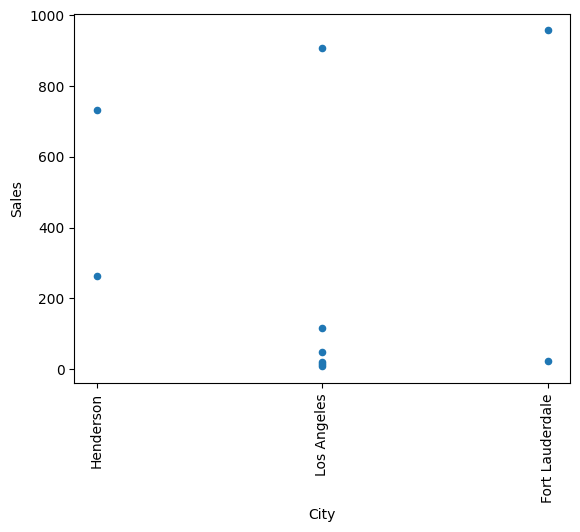

In [7]:
# Total of sales by city TOP 10
df_superstore.head(10).plot(kind='scatter', x='City', y='Sales')
plt.xticks(rotation=90)
plt.show()

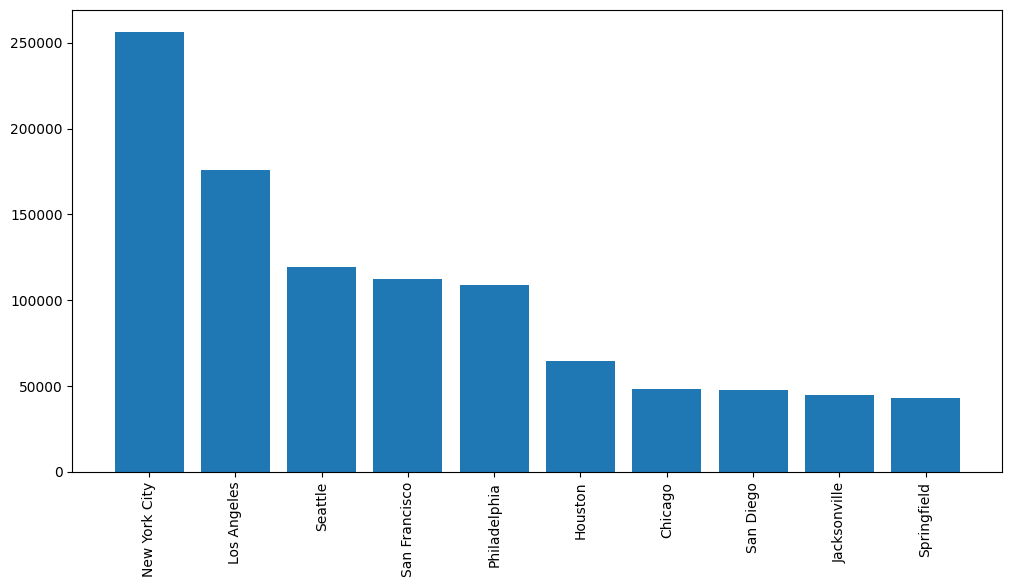

In [8]:
sales_by_city = (
    df_superstore
    .groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 6))
plt.bar(sales_by_city.index, sales_by_city.values)
plt.xticks(rotation=90)

plt.show()


In [9]:
df_superstore['Region'].nunique()

4

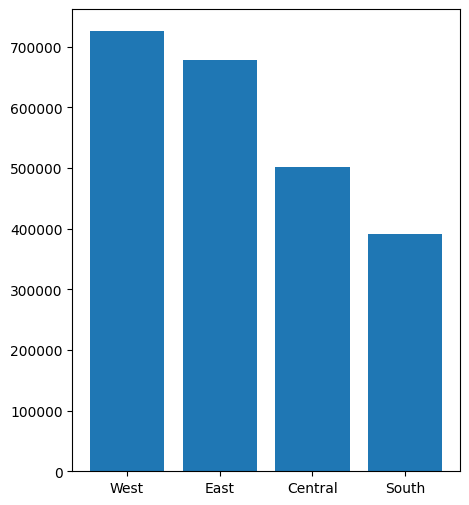

In [10]:
sales_by_region = (
    df_superstore
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(5, 6))
plt.bar(sales_by_region.index, sales_by_region.values)

plt.show()

In [11]:
df_superstore['Category'].nunique()

3

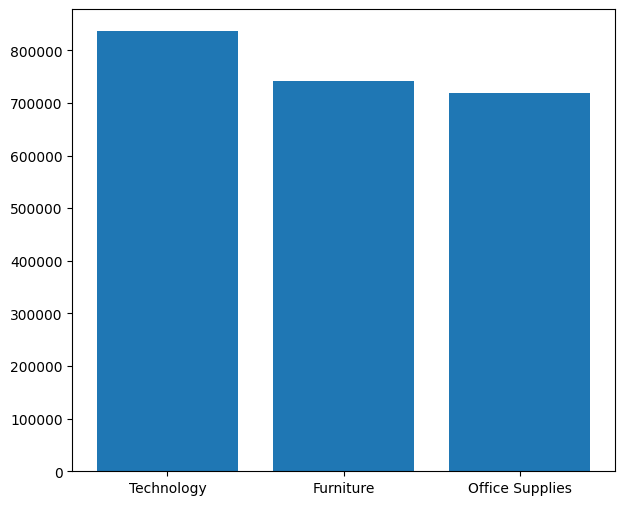

In [12]:
sales_by_category = (
    df_superstore
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(7, 6))
plt.bar(sales_by_category.index, sales_by_category.values)


plt.show()

In [13]:
df_superstore['Customer ID'].nunique()

793

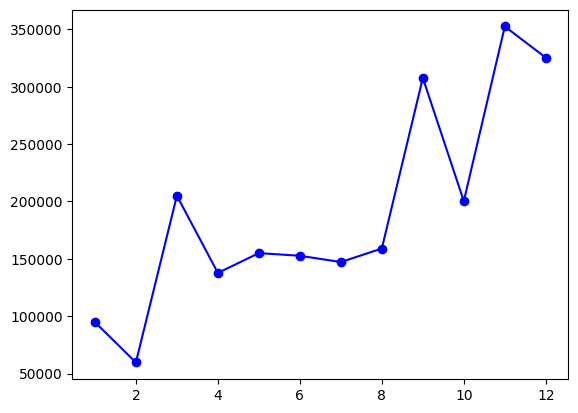

In [14]:

sales_by_month=(
    df_superstore
    .groupby(df_superstore["Order Date"].dt.month)["Sales"]
    .sum()
)
plt.plot(sales_by_month.index, sales_by_month.values,marker="o", linestyle='-', color="blue")
plt.show()





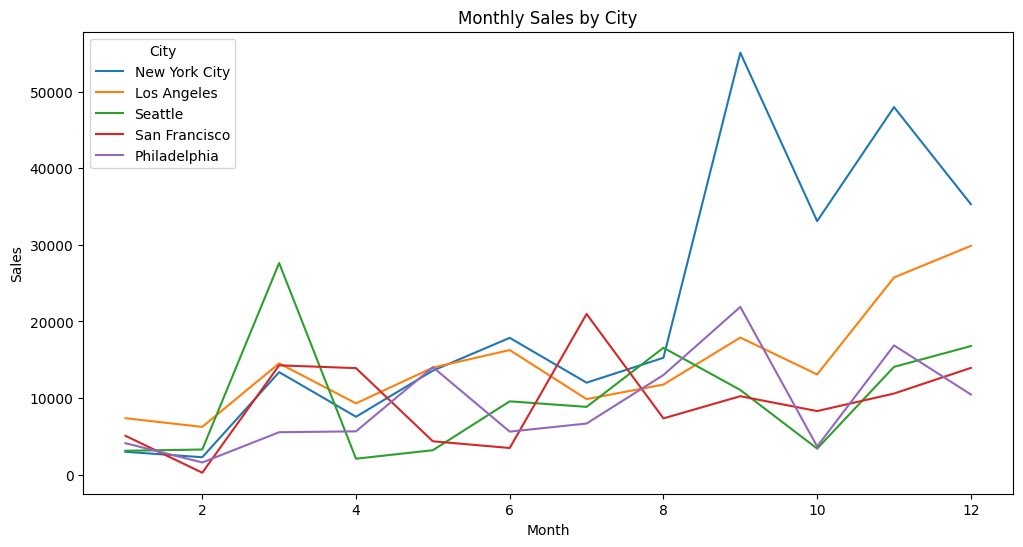

In [15]:
df_superstore["Month"] = df_superstore["Order Date"].dt.month


top5 = (
    df_superstore
    .groupby('City')['Sales']
    .sum()
    .nlargest(5)
    .index
)



sales_by_month_city = (
    df_superstore
    .groupby(["Month", "City"])["Sales"]
    .sum()
    .unstack()[top5]
    
)
sales_by_month_city.plot(figsize=(12,6))

plt.title("Monthly Sales by City")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

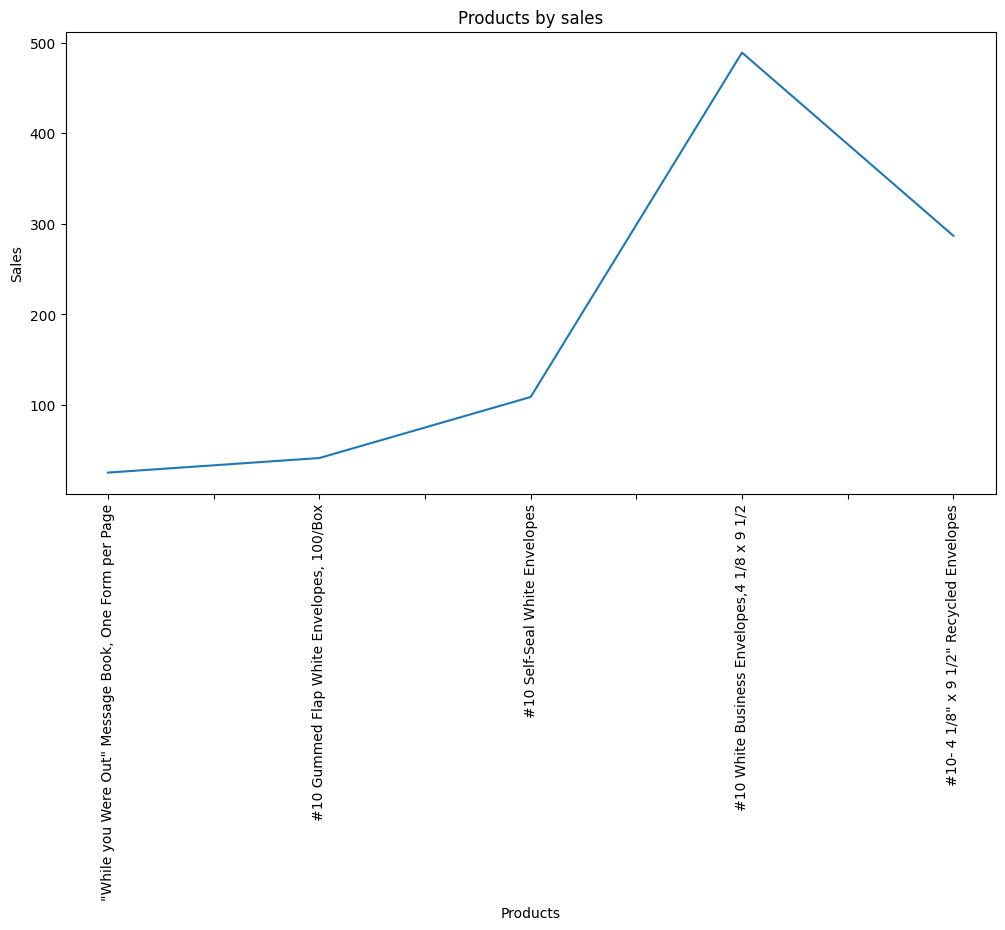

In [21]:
products_by_Sales = (
    df_superstore
    .groupby("Product Name")["Sales"]
    .sum()
    .head(5)
    
)
products_by_Sales.plot(figsize=(12,6))

plt.title("Products by sales")
plt.xlabel("Products")
plt.ylabel("Sales")
plt.xticks(rotation=90)

plt.show()